# MLP Neural Network for Music Genre Classification
## Using Class Balancing with Sample Weights

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

### Load Dataset

In [4]:
# Load final dataset
print("Loading dataset...")
df = pd.read_csv("../../data/processed/final_dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Loading dataset...
Dataset shape: (685567, 15)


,track_name,artist_name,genre,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_sec,popularity,macro_genre
0,I Won't Give Up,Jason Mraz,acoustic,-0.295121,-1.244639,-1.178954,1.049226,-0.691216,-0.537222,-0.393524,0.403917,-0.189488,-0.062859,3.123384,Acoustic
1,93 Million Miles,Jason Mraz,acoustic,0.187328,-0.686411,0.221331,0.437937,-0.691179,-0.624753,-0.528338,0.631455,-0.229613,-0.221997,1.990284,Acoustic
2,Do Not Let Me Go,Joshua Hyslop,acoustic,-0.696259,-1.499723,-1.156609,0.046373,-0.691079,-0.664042,-0.477093,0.619702,-0.832373,-0.606319,2.430934,Acoustic
3,Fast Car,Boyce Avenue,acoustic,-0.788412,-1.436876,0.195262,1.367548,-0.691216,-0.712781,-0.445557,2.806734,-0.152002,0.366301,2.493884,Acoustic
4,Sky's Still Blue,Andrew Belle,acoustic,-0.582422,0.559434,-0.888469,-0.701259,-0.638350,-0.562088,-0.493649,1.695337,0.626921,-0.035059,2.242084,Acoustic


### Data Preprocessing

In [5]:
# Define features & target
feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness'
]

keep_genres = ['Acoustic', 'Electronic', 'Hip-Hop', 'Latin', 'Metal']
df = df[df['macro_genre'].isin(keep_genres)]

X = df[feature_cols].values
y = df['macro_genre'].values

Filtered dataset size: 685567


### Check Class Distribution

In [7]:
# Check class distribution
unique, counts = np.unique(y, return_counts=True)
for genre, count in zip(unique, counts):
    print(f"{genre}: {count} samples ({count/len(y)*100:.1f}%)")

Acoustic: 163542 samples (23.9%)
Electronic: 235768 samples (34.4%)
Hip-Hop: 26988 samples (3.9%)
Latin: 107272 samples (15.6%)
Metal: 151997 samples (22.2%)


### Train/Test Split

In [8]:
# Train/test split
n = len(X)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 548453
Test set size: 137114


### Compute Class Weights

In [9]:
# Compute class weights for balancing
print("\nComputing class weights...")
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create sample weights for training
sample_weights = np.array([class_weight_dict[label] for label in y_train])

print("Class weights:")
for genre, weight in class_weight_dict.items():
    print(f"  {genre}: {weight:.4f}")


Computing class weights...
Class weights:
  Acoustic: 0.8385
  Electronic: 0.5816
  Hip-Hop: 5.0549
  Latin: 1.2798
  Metal: 0.9018


### Feature Scaling

In [10]:
# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")


Scaling features...
Scaling complete!


### Build and Train MLP Model

In [11]:
# Build and Train MLP Neural Network with Class Balancing
print("\n" + "=" * 60)
print("Training MLP Neural Network with Class Balancing")
print("=" * 60)
print("Architecture: 128 -> 64 -> 32 hidden layers")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=200,
    random_state=42,
    verbose=True  # Show training progress
)

# Train the model with sample weights
print("\nFitting model...")
mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print("\nTraining complete!")


Training MLP Neural Network with Class Balancing
Architecture: 128 -> 64 -> 32 hidden layers

Fitting model...
Iteration 1, loss = 0.86542608
Iteration 2, loss = 0.83226852
Iteration 3, loss = 0.82377936
Iteration 4, loss = 0.81857857
Iteration 5, loss = 0.81478415
Iteration 6, loss = 0.81194597
Iteration 7, loss = 0.80938040
Iteration 8, loss = 0.80750867
Iteration 9, loss = 0.80601402
Iteration 10, loss = 0.80375405
Iteration 11, loss = 0.80304919
Iteration 12, loss = 0.80126867
Iteration 13, loss = 0.80049761
Iteration 14, loss = 0.79901078
Iteration 15, loss = 0.79850625
Iteration 16, loss = 0.79721846
Iteration 17, loss = 0.79650407
Iteration 18, loss = 0.79581619
Iteration 19, loss = 0.79451219
Iteration 20, loss = 0.79406090
Iteration 21, loss = 0.79320065
Iteration 22, loss = 0.79288617
Iteration 23, loss = 0.79214846
Iteration 24, loss = 0.79152349
Iteration 25, loss = 0.79092197
Iteration 26, loss = 0.79020045
Iteration 27, loss = 0.78975750
Iteration 28, loss = 0.78934941
I

/Users/prionti/PycharmProjects/CSCI-635-01-Group-4/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Make Predictions and Evaluate

In [12]:
# Make predictions
print("Making predictions...")
y_pred = mlp.predict(X_test_scaled)

# Evaluate
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\n{'MLP Neural Network Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc:.2%}")
print(f"F1 Score (macro): {f1:.4f}")

Making predictions...

                 MLP Neural Network Results                 
Accuracy: 69.64%
F1 Score (macro): 0.6458


### Classification Report

In [13]:
print("\n" + "=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.83      0.72      0.77     32730
  Electronic       0.83      0.62      0.71     47171
     Hip-Hop       0.18      0.63      0.28      5288
       Latin       0.69      0.75      0.72     21562
       Metal       0.74      0.76      0.75     30363

    accuracy                           0.70    137114
   macro avg       0.65      0.70      0.65    137114
weighted avg       0.76      0.70      0.72    137114



### Confusion Matrix

In [14]:
# Confusion Matrix
print("\n" + "=" * 60)
print("Confusion Matrix:")
print("=" * 60)
cm = confusion_matrix(y_test, y_pred, labels=keep_genres)
print(cm)


Confusion Matrix:
[[23704  1504  2860  2826  1836]
 [ 1754 29147  7806  3240  5224]
 [  322   994  3333   429   210]
 [ 1626   905  1876 16272   883]
 [ 1123  2581  2670   957 23032]]


### Visualize Confusion Matrix

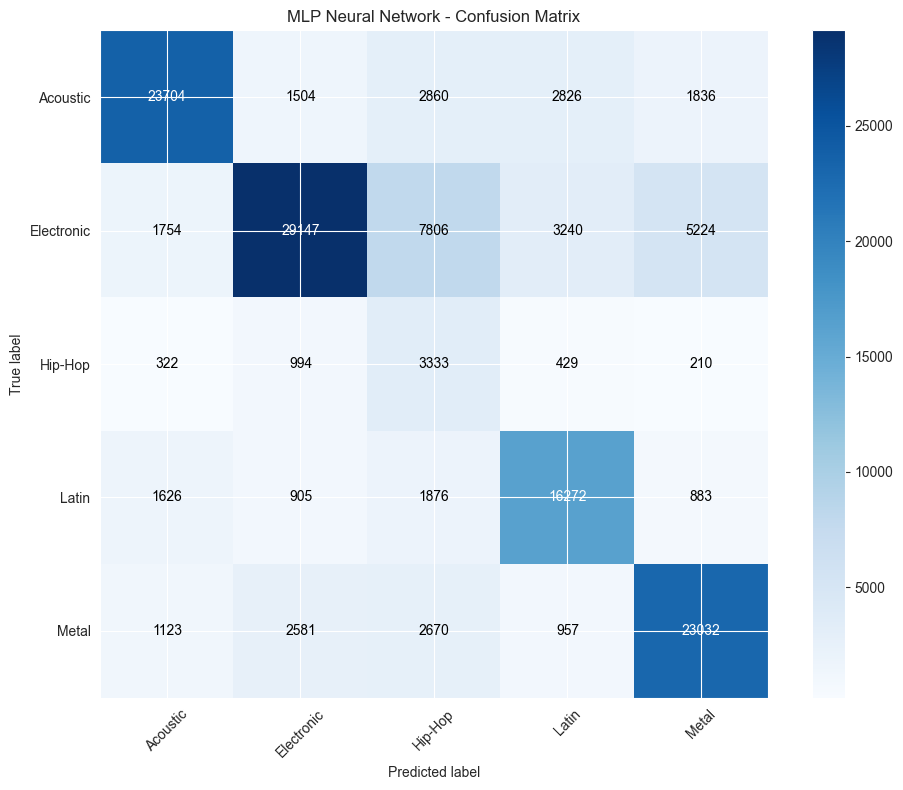


Confusion matrix saved as 'mlp_confusion_matrix.png'


In [15]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('MLP Neural Network - Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(keep_genres))
plt.xticks(tick_marks, keep_genres, rotation=45)
plt.yticks(tick_marks, keep_genres)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nConfusion matrix saved as 'mlp_confusion_matrix.png'")